<h4>By using Mean Median for imputation of missing values

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [102]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [103]:
df=pd.read_csv('titanic_toy.csv')

In [104]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [106]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [107]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['Survived'])
y =df['Survived']

In [108]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

<h5>Calculate the Mean and Medain of Age and Fare columns

In [109]:
age_mean=x_train['Age'].mean()
age_median=x_train['Age'].median()
#Mean and Median for far column
fare_mean=x_train['Fare'].mean()
fare_median=x_train['Fare'].mean()

<h5>Fill the missing value and add new columns age mean, age median...

In [110]:
x_train['Age mean']=x_train['Age'].fillna(age_mean)
x_train['Age median']=x_train['Age'].fillna(age_median)

x_train['fare mean']=x_train['Fare'].fillna(fare_mean)
x_train['fare median']=x_train['Fare'].fillna(fare_median)



In [111]:
x_test['Age mean'] = x_test['Age'].fillna(age_mean)
x_test['Age median'] = x_test['Age'].fillna(age_median)

x_test['fare mean'] = x_test['Fare'].fillna(fare_mean)
x_test['fare median'] = x_test['Fare'].fillna(fare_median)


In [112]:
x_test

,Age,Fare,Family,Age mean,Age median,fare mean,fare median
707,42.0,26.2875,0,42.000000,42.00,26.287500,26.287500
37,21.0,8.0500,0,21.000000,21.00,8.050000,8.050000
615,24.0,65.0000,3,24.000000,24.00,65.000000,65.000000
169,28.0,56.4958,0,28.000000,28.00,56.495800,56.495800
68,17.0,7.9250,6,17.000000,17.00,7.925000,7.925000
...,...,...,...,...,...,...,...
89,24.0,8.0500,0,24.000000,24.00,8.050000,8.050000
80,22.0,9.0000,0,22.000000,22.00,9.000000,9.000000
846,NaN,69.5500,10,29.785904,28.75,69.550000,69.550000
870,26.0,7.8958,0,26.000000,26.00,7.895800,7.895800


In [113]:
#Check the variance Before and After
print('Before fillna by mean and median variance of the data',x_train['Age'].var())
print(f'After fillna by mean and median variacne of the data \nBy Mean:{x_train["Age mean"].var()}\nBy median:{x_train["Age median"].var()} ')


Before fillna by mean and median variance of the data 204.34951339046142
After fillna by mean and median variacne of the data 
By Mean:161.81262452718676
By median:161.98956633460548 


In [114]:
#Check the variance Before and After fare 
print('Before fillna by mean and median variance of the data',x_train['Fare'].var())
print(f'After fillna by mean and median variacne of the data \nBy Mean:{x_train["fare mean"].var()}\nBy median:{x_train["fare median"].var()} ')


Before fillna by mean and median variance of the data 2448.1979137063163
After fillna by mean and median variacne of the data 
By Mean:2324.2385256705534
By median:2324.2385256705534 


<h5>Graphical Representation

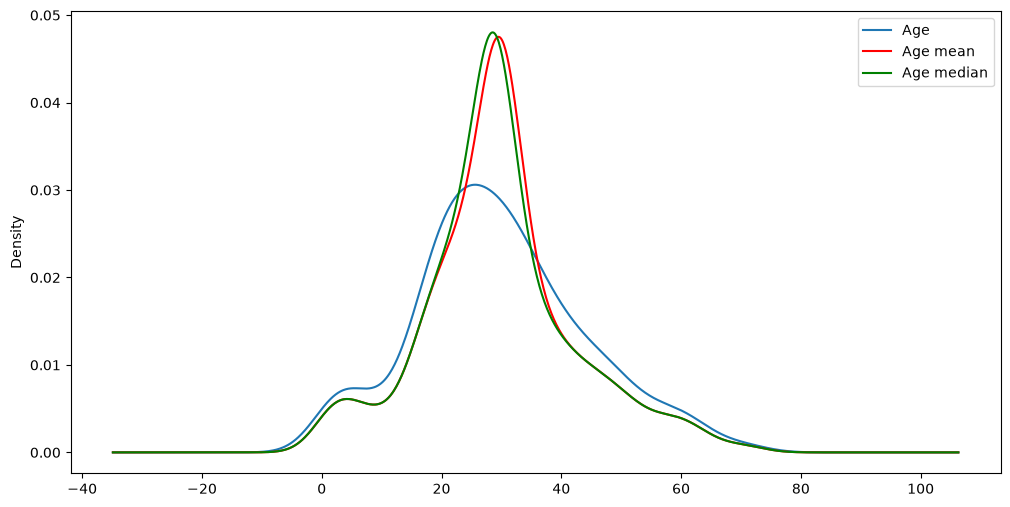

In [115]:
fig,ax=plt.subplots(figsize=(12,6))
x_train['Age'].plot(kind='kde',ax=ax,label='Age')
#Fare mean plot
x_train['Age mean'].plot(kind='kde',ax=ax,color='red',label='Age mean')
#Fare Median plot
x_train['Age median'].plot(kind='kde',ax=ax,color='green',label='Age median')
ax.legend()
plt.show()

<h4>We can't use mean and median transformation for Age column because the real information are change a lot and the missing value percentage is 20% higher then 5%

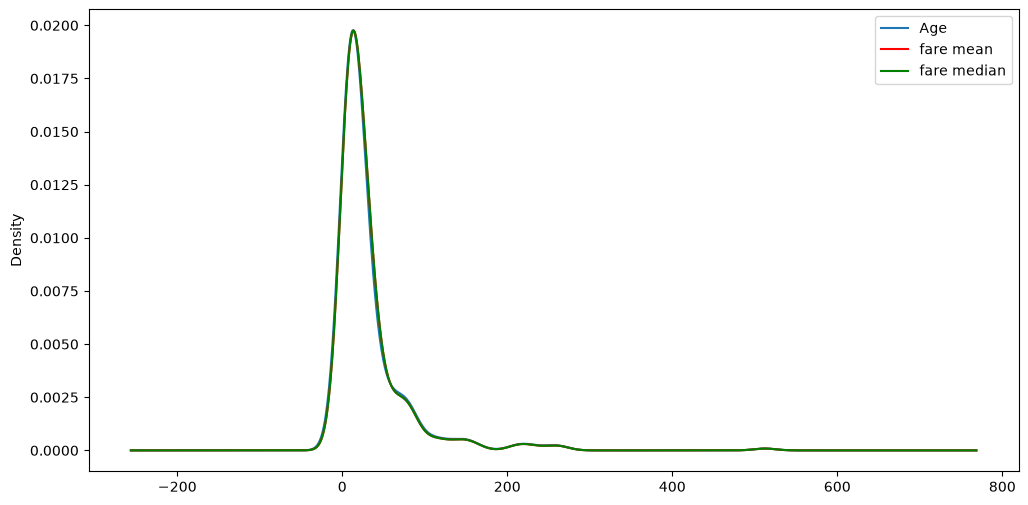

In [116]:
fig,ax=plt.subplots(figsize=(12,6))
x_train['Fare'].plot(kind='kde',ax=ax,label='Age')
#Fare mean plot
x_train['fare mean'].plot(kind='kde',ax=ax,color='red',label='fare mean')
#Fare Median plot
x_train['fare median'].plot(kind='kde',ax=ax,color='green',label='fare median')
ax.legend()
plt.show()

<h5>Change in Covariance and Correlatoin

In [117]:
x_train.cov()

,Age,Fare,Family,Age mean,Age median,fare mean,fare median
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.665205,66.665205
Fare,70.719262,2448.197914,17.258917,55.603719,57.957599,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.146106,-5.112563,16.385048,16.385048
Age mean,204.349513,55.603719,-5.146106,161.812625,161.812625,52.788341,52.788341
Age median,204.349513,57.957599,-5.112563,161.812625,161.989566,55.023037,55.023037
fare mean,66.665205,2448.197914,16.385048,52.788341,55.023037,2324.238526,2324.238526
fare median,66.665205,2448.197914,16.385048,52.788341,55.023037,2324.238526,2324.238526


In [118]:
x_train.corr()

,Age,Fare,Family,Age mean,Age median,fare mean,fare median
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.090156,0.090156
Fare,0.092644,1.000000,0.208268,0.088069,0.091757,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.244610,-0.242883,0.205499,0.205499
Age mean,1.000000,0.088069,-0.244610,1.000000,0.999454,0.086078,0.086078
Age median,1.000000,0.091757,-0.242883,0.999454,1.000000,0.089673,0.089673
fare mean,0.090156,1.000000,0.205499,0.086078,0.089673,1.000000,1.000000
fare median,0.090156,1.000000,0.205499,0.086078,0.089673,1.000000,1.000000


<h4>Using box plot check the outliers

<Axes: >

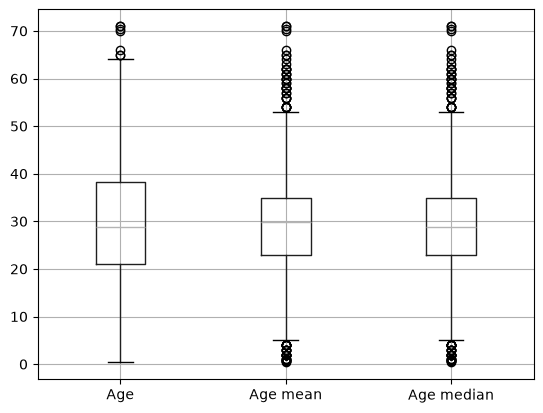

In [119]:
x_train[['Age','Age mean','Age median']].boxplot()

<Axes: >

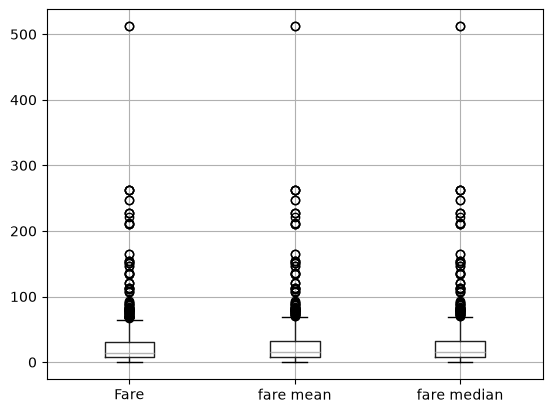

In [120]:
x_train[['Fare','fare mean','fare median']].boxplot()

<h4>Mean Median by sklearn

In [121]:
imputer1=SimpleImputer(strategy='mean')
imputer2=SimpleImputer(strategy='median')

In [122]:
mm=ColumnTransformer(
    [('imputer1',imputer1,[0]),('imputer2',imputer2,[1])],
    remainder='passthrough'   
)

In [123]:
mm.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [124]:
mm.named_transformers_['imputer1'].statistics_

array([29.78590426])

In [125]:
mm.named_transformers_['imputer2'].statistics_

array([14.4583])

In [126]:
x_train=mm.transform(x_train)
x_test=mm.transform(x_test)

In [140]:
transformed_df=pd.DataFrame(x_train[:,:3],columns=df.columns[:3])

In [141]:
transformed_df.head()

,Age,Fare,Family
0,40.0,27.7208,0.0
1,4.0,16.7000,2.0
2,47.0,9.0000,0.0
3,9.0,31.3875,6.0
4,20.0,9.8458,0.0


In [143]:
transformed_df.isnull().sum()

Age       0
Fare      0
Family    0
dtype: int64